# Upstream tutorial: ChIP-seq

This notebook is an `epione`-native rewrite of the Galaxy Training Network TAL1 ChIP-seq tutorial. The goal is to start from raw ChIP and input FASTQ files, preprocess each replicate, merge replicates into experiment-level BAMs, generate browser-ready bigWig tracks, call peaks with an input control, and finally inspect the signal around a tutorial-relevant locus and around transcription start sites.

Unlike the previous upstream notebooks, this tutorial uses **single-end** ChIP-seq reads. That is important because it demonstrates why the new `epione.align.*` package is a better home for upstream logic than the old bulk-only wrappers: the same alignment layer now supports both paired-end and single-end sequencing inputs.

The teaching dataset comes from the Galaxy TAL1 lesson and includes both ChIP and matched input FASTQs. To keep the notebook executable in `omicdev`, we use a reduced `chr4` mouse reference and reuse the TAL1 locus from the Galaxy-provided regions-of-interest BED file.


> **Scope note.** This notebook covers the *upstream* part of a single-end ChIP-seq workflow: `FASTQ -> filtered BAM -> merged BAM -> bigWig -> input-controlled peaks -> visual QC`. It does **not** cover motif discovery, differential binding, or replicate correlation plots.

### Data provenance

The example files are from the Galaxy Training Network TAL1 ChIP-seq tutorial and are hosted on Zenodo. We use the **G1E** ChIP and input replicates because they provide both raw FASTQ controls and a compact tutorial-scale signal structure.

| Item | Source | How it is used here |
| --- | --- | --- |
| **G1E TAL1 R1/R2** | Galaxy GTN TAL1 tutorial | Single-end ChIP replicates for the target factor. |
| **G1E input R1/R2** | Galaxy GTN TAL1 tutorial | Matched single-end control replicates used for MACS2 control subtraction. |
| **Regions of interest BED** | Galaxy GTN TAL1 tutorial | Supplies the `Tal1` tutorial locus for browser-style visualization. |
| **GRCm38 FASTA + Gencode annotation** | `epione` dataset fetcher | Used to derive a lightweight `chr4` demo reference and matching transcript annotation. |

### Learning goals

By the end of the notebook, you should be able to answer five practical questions:

1. How does `epione.align` handle single-end ChIP-seq inputs?
2. Which preprocessing steps are replicate-specific, and which are experiment-level?
3. How do we call MACS2 peaks with a matched input control through `epione`?
4. How can we reuse a Galaxy tutorial locus inside `epi.bulk.bigwig` visualization?
5. How can the same `epi.align.*` API be transferred to real project ChIP-seq samples?


## 1. Check upstream tools

The `epione.align` namespace keeps the alignment and file-conversion layer explicit. For this ChIP-seq tutorial, the critical external binaries are still the standard aligner and interval-processing tools, while bigWig writing and TSS aggregation are handled inside Python.


In [2]:
import epione as epi

epi.align.check_tools([
    'bowtie2',
    'samtools',
    'bedtools',
    'macs2',
])


/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/_registry.py:241: UserWarning: Function 'omicverse.alignment.dada2.merge_pairs' is missing a docstring; agent help output may be limited.
  warnings.warn(
/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/_registry.py:241: UserWarning: Function 'omicverse.alignment.dada2.make_seqtab' is missing a docstring; agent help output may be limited.
  warnings.warn(
/scratch/users/steorra/analysis/omicverse_dev/omicverse/omicverse/_registry.py:241: UserWarning: Function 'omicverse.alignment.dada2.remove_chimeras' is missing a docstring; agent help output may be limited.
  warnings.warn(


  ✗  bowtie2                    NOT FOUND
  ✗  samtools                   NOT FOUND
  ✗  bedtools                   NOT FOUND
  ✗  macs2                      NOT FOUND


{'bowtie2': None, 'samtools': None, 'bedtools': None, 'macs2': None}

## 2. Download the Galaxy ChIP and input FASTQs

The TAL1 lesson ships both ChIP and matched input as single-end FASTQ replicates, which makes it more suitable than the previous toy ChIP example. We also download the Galaxy-provided regions-of-interest BED so that later visualization can reuse the `Tal1` locus from the teaching material.


In [3]:
import os
import pathlib
import urllib.request
import warnings

import pandas as pd
import epione as epi

warnings.filterwarnings('ignore', message='Function .* is missing a docstring.*')
os.environ['LC_ALL'] = 'C'
os.environ['LC_CTYPE'] = 'C'

epi.pl.plot_set()

WORK = pathlib.Path.cwd()
DATA = WORK / 'galaxy_chipseq_demo'
FASTQ_DIR = DATA / 'fastq'
REF_DIR = DATA / 'ref'
OUT = DATA / 'result'
for p in [FASTQ_DIR, REF_DIR, OUT]:
    p.mkdir(parents=True, exist_ok=True)

CHIP_URLS = {
    'G1E_Tal1_R1.fastqsanger': 'https://zenodo.org/api/records/197100/files/G1E_Tal1_R1_downsampled_SRR492444.fastqsanger/content',
    'G1E_Tal1_R2.fastqsanger': 'https://zenodo.org/api/records/197100/files/G1E_Tal1_R2_downsampled_SRR492445.fastqsanger/content',
    'G1E_input_R1.fastqsanger': 'https://zenodo.org/api/records/197100/files/G1E_input_R1_downsampled_SRR507859.fastqsanger/content',
    'G1E_input_R2.fastqsanger': 'https://zenodo.org/api/records/197100/files/G1E_input_R2_downsampled_SRR507860.fastqsanger/content',
    'ChIPseq_regions_of_interest_v4.bed': 'https://zenodo.org/api/records/197100/files/ChIPseq_regions_of_interest_v4.bed/content',
}


└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



In [4]:
for name, url in CHIP_URLS.items():
    out = FASTQ_DIR / name
    if not out.exists():
        print(f'downloading {name} ...')
        urllib.request.urlretrieve(url, out)
    else:
        print(f'skip existing: {name}')

chip_reps = [
    ('Tal1_R1', FASTQ_DIR / 'G1E_Tal1_R1.fastqsanger'),
    ('Tal1_R2', FASTQ_DIR / 'G1E_Tal1_R2.fastqsanger'),
]
input_reps = [
    ('Input_R1', FASTQ_DIR / 'G1E_input_R1.fastqsanger'),
    ('Input_R2', FASTQ_DIR / 'G1E_input_R2.fastqsanger'),
]
regions_bed = FASTQ_DIR / 'ChIPseq_regions_of_interest_v4.bed'

pd.DataFrame({
    'sample': [s for s, _ in chip_reps + input_reps],
    'fastq': [str(fq) for _, fq in chip_reps + input_reps],
})


skip existing: G1E_Tal1_R1.fastqsanger
skip existing: G1E_Tal1_R2.fastqsanger
skip existing: G1E_input_R1.fastqsanger
skip existing: G1E_input_R2.fastqsanger
skip existing: ChIPseq_regions_of_interest_v4.bed


,sample,fastq
0,Tal1_R1,/scratch/users/steorra/analysis/omicverse_dev/...
1,Tal1_R2,/scratch/users/steorra/analysis/omicverse_dev/...
2,Input_R1,/scratch/users/steorra/analysis/omicverse_dev/...
3,Input_R2,/scratch/users/steorra/analysis/omicverse_dev/...


## 3. Prepare a `chr4` mouse demo reference

The Galaxy regions-of-interest file includes a `Tal1` locus on `chr4`, so we use `chr4` as the reduced executable reference. This keeps index construction small enough for a notebook run while preserving a locus that is explicitly part of the GTN teaching materials.


In [4]:
%%time
from pyfaidx import Fasta

MM10_FASTA = pathlib.Path(epi.align.fetch_genome_fasta('GRCm38'))
CHR4_FASTA = REF_DIR / 'chr4.fa'
CHR4_BT2_PREFIX = REF_DIR / 'chr4'

fa = Fasta(str(MM10_FASTA))
CHR4_SIZE = len(fa['chr4'])
if not CHR4_FASTA.exists():
    with open(CHR4_FASTA, 'w') as fout:
        fout.write('>chr4\n')
        seq = str(fa['chr4'])
        for i in range(0, len(seq), 60):
            fout.write(seq[i:i+60] + '\n')

ref = epi.align.prepare_reference(
    fasta=CHR4_FASTA,
    aligner='bowtie2',
    index_prefix=CHR4_BT2_PREFIX,
)
ref


CPU times: user 472 ms, sys: 122 ms, total: 594 ms
Wall time: 598 ms


{'fasta': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/ref/chr4.fa',
 'fai': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/ref/chr4.fa.fai',
 'chrom_sizes': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/ref/chr4.chrom.sizes',
 'ref_index': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/ref/chr4'}

## 4. Process single-end ChIP and input replicates step by step

The TAL1 lesson contains both ChIP FASTQs and matched input FASTQs, so we can express the complete single-end backbone explicitly for both signal and control.

For every replicate we run the same sequence of operations:

1. `epi.align.bowtie2.align_fastq_to_bam(...)` aligns the single-end reads and performs duplicate removal.
2. `epi.align.samtools.filter_bam(...)` applies the mapping-quality and flag filters appropriate for single-end data.
3. `epi.align.samtools.index_bam(...)` makes the filtered BAM directly reusable.
4. `epi.align.bigwig.bam_to_bigwig(...)` exports the signal track used for browser-style inspection.

This makes the control logic obvious: input is not a special file type here, just another single-end alignment stream processed with the same core machinery.


In [5]:
%%time
chip_runs = {}
for sample_name, fq in chip_reps:
    sample_dir = OUT / sample_name
    sample_dir.mkdir(parents=True, exist_ok=True)
    raw_bam = sample_dir / f'{sample_name}.raw.bam'
    filt_bam = sample_dir / f'{sample_name}.filtered.bam'
    bw_path = sample_dir / f'{sample_name}.rpkm.bw'

    for stale in [raw_bam, filt_bam, pathlib.Path(str(filt_bam) + '.bai'), bw_path]:
        if stale.exists():
            stale.unlink()

    epi.align.bowtie2.align_fastq_to_bam(
        fq1=str(fq),
        fq2=None,
        out_bam=raw_bam,
        ref_index=ref['ref_index'],
        threads=8,
        extra_args=['--very-sensitive'],
        remove_duplicates=True,
    )
    epi.align.samtools.filter_bam(
        raw_bam,
        filt_bam,
        mapq=30,
        proper_pair=False,
        drop_secondary_supp=True,
        drop_duplicates=False,
        drop_qcfail=False,
        drop_unmapped=True,
        drop_mate_unmapped=False,
        threads=8,
    )
    epi.align.samtools.index_bam(filt_bam, threads=8)
    epi.align.bigwig.bam_to_bigwig(
        filt_bam,
        bw_path,
        bin_size=25,
        normalize_using='RPKM',
        threads=8,
    )
    raw_bam.unlink(missing_ok=True)
    chip_runs[sample_name] = {'bam': str(filt_bam), 'bigwig': str(bw_path)}

input_runs = {}
for sample_name, fq in input_reps:
    sample_dir = OUT / sample_name
    sample_dir.mkdir(parents=True, exist_ok=True)
    raw_bam = sample_dir / f'{sample_name}.raw.bam'
    filt_bam = sample_dir / f'{sample_name}.filtered.bam'
    bw_path = sample_dir / f'{sample_name}.rpkm.bw'

    for stale in [raw_bam, filt_bam, pathlib.Path(str(filt_bam) + '.bai'), bw_path]:
        if stale.exists():
            stale.unlink()

    epi.align.bowtie2.align_fastq_to_bam(
        fq1=str(fq),
        fq2=None,
        out_bam=raw_bam,
        ref_index=ref['ref_index'],
        threads=8,
        extra_args=['--very-sensitive'],
        remove_duplicates=True,
    )
    epi.align.samtools.filter_bam(
        raw_bam,
        filt_bam,
        mapq=30,
        proper_pair=False,
        drop_secondary_supp=True,
        drop_duplicates=False,
        drop_qcfail=False,
        drop_unmapped=True,
        drop_mate_unmapped=False,
        threads=8,
    )
    epi.align.samtools.index_bam(filt_bam, threads=8)
    epi.align.bigwig.bam_to_bigwig(
        filt_bam,
        bw_path,
        bin_size=25,
        normalize_using='RPKM',
        threads=8,
    )
    raw_bam.unlink(missing_ok=True)
    input_runs[sample_name] = {'bam': str(filt_bam), 'bigwig': str(bw_path)}

{
    'chip': pd.DataFrame(chip_runs).T,
    'input': pd.DataFrame(input_runs).T,
}


[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


344016 reads; of these:
  344016 (100.00%) were unpaired; of these:
    297031 (86.34%) aligned 0 times
    7181 (2.09%) aligned exactly 1 time
    39804 (11.57%) aligned >1 times
13.66% overall alignment rate
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


602243 reads; of these:
  602243 (100.00%) were unpaired; of these:
    525902 (87.32%) aligned 0 times
    12531 (2.08%) aligned exactly 1 time
    63810 (10.60%) aligned >1 times
12.68% overall alignment rate
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


...

[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default


3324017 reads; of these:
  3324017 (100.00%) were unpaired; of these:
    2912651 (87.62%) aligned 0 times
    55349 (1.67%) aligned exactly 1 time
    356017 (10.71%) aligned >1 times
12.38% overall alignment rate
[bam_sort_core] merging from 0 files and 8 in-memory blocks...


[bam_sort_core] merging from 0 files and 8 in-memory blocks...


CPU times: user 2min 5s, sys: 2.53 s, total: 2min 7s
Wall time: 2min 37s


{'chip':                                                        bam  \
 Tal1_R1  /scratch/users/steorra/analysis/omicverse_dev/...   
 Tal1_R2  /scratch/users/steorra/analysis/omicverse_dev/...   
 
                                                     bigwig  
 Tal1_R1  /scratch/users/steorra/analysis/omicverse_dev/...  
 Tal1_R2  /scratch/users/steorra/analysis/omicverse_dev/...  ,
 'input':                                                         bam  \
 Input_R1  /scratch/users/steorra/analysis/omicverse_dev/...   
 Input_R2  /scratch/users/steorra/analysis/omicverse_dev/...   
 
                                                      bigwig  
 Input_R1  /scratch/users/steorra/analysis/omicverse_dev/...  
 Input_R2  /scratch/users/steorra/analysis/omicverse_dev/...  }

## 5. Merge ChIP and input replicates

The next transition is from replicate-level preprocessing to experiment-level summarisation. We merge the filtered ChIP replicates into one signal BAM, merge the filtered input replicates into one control BAM, and then export bigWigs for both.

This preserves the matched-control logic very transparently:

| Alignment set | Operation | Result |
| --- | --- | --- |
| **ChIP replicates** | `epi.align.samtools.merge_bams(...)` | Experiment-level signal BAM and bigWig. |
| **Input replicates** | `epi.align.samtools.merge_bams(...)` | Experiment-level control BAM and bigWig. |

The merged BAMs are the objects used by the downstream peak-calling step.


In [6]:
%%time
merged_dir = OUT / 'merged'
merged_dir.mkdir(parents=True, exist_ok=True)
for stale in [
    merged_dir / 'Tal1.filtered.bam',
    merged_dir / 'Tal1.filtered.bam.bai',
    merged_dir / 'Tal1.rpkm.bw',
    merged_dir / 'Input.filtered.bam',
    merged_dir / 'Input.filtered.bam.bai',
    merged_dir / 'Input.rpkm.bw',
]:
    if stale.exists():
        stale.unlink()

merged_chip_bam = epi.align.samtools.merge_bams(
    [chip_runs['Tal1_R1']['bam'], chip_runs['Tal1_R2']['bam']],
    merged_dir / 'Tal1.filtered.bam',
    threads=8,
    index=True,
)
merged_input_bam = epi.align.samtools.merge_bams(
    [input_runs['Input_R1']['bam'], input_runs['Input_R2']['bam']],
    merged_dir / 'Input.filtered.bam',
    threads=8,
    index=True,
)
merged_chip_bw = epi.align.bigwig.bam_to_bigwig(
    merged_chip_bam,
    merged_dir / 'Tal1.rpkm.bw',
    bin_size=25,
    normalize_using='RPKM',
    threads=8,
)
merged_input_bw = epi.align.bigwig.bam_to_bigwig(
    merged_input_bam,
    merged_dir / 'Input.rpkm.bw',
    bin_size=25,
    normalize_using='RPKM',
    threads=8,
)
{
    'merged_chip_bam': merged_chip_bam,
    'merged_input_bam': merged_input_bam,
    'merged_chip_bigwig': merged_chip_bw,
    'merged_input_bigwig': merged_input_bw,
}


CPU times: user 1min 2s, sys: 1.3 s, total: 1min 4s
Wall time: 1min 4s


{'merged_chip_bam': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Tal1.filtered.bam',
 'merged_input_bam': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Input.filtered.bam',
 'merged_chip_bigwig': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Tal1.rpkm.bw',
 'merged_input_bigwig': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Input.rpkm.bw'}

In [7]:
merged_chip_bam='/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Tal1.filtered.bam'
merged_input_bam='/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Input.filtered.bam'
merged_chip_bigwig='/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Tal1.rpkm.bw'
merged_input_bigwig='/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Input.rpkm.bw'


## 6. Call peaks with a matched input control

This is the key ChIP-specific statistical step. The merged TAL1 BAM supplies the signal, while the merged input BAM supplies the matched background model.

### The function

`epi.align.macs2.call_peaks_macs2(...)` wraps the standard MACS2 callpeak interface.

| Key parameter | What it controls |
| --- | --- |
| `bam` | Signal alignment used as the treatment set. |
| `control_bam` | Matched input alignment used as the control set. |
| `format='BAM'` | Treats the data as single-end reads. |
| `nomodel=False` | Leaves MACS2 model building enabled for this single-end ChIP example. |

Because the notebook uses a reduced `chr4` reference, the goal is to reproduce the tutorial logic on a compact locus-focused dataset rather than generate a full-genome binding map.


In [7]:
%%time
merged_chip_bam = OUT / 'merged' / 'Tal1.filtered.bam'
merged_input_bam = OUT / 'merged' / 'Input.filtered.bam'
peak_paths = epi.align.macs2.call_peaks_macs2(
    bam=merged_chip_bam,
    control_bam=merged_input_bam,
    out_dir=OUT / 'peaks',
    name='G1E_Tal1',
    genome_size=str(CHR4_SIZE),
    format='BAM',
    qvalue=0.01,
    keep_dup='all',
    call_summits=True,
    nomodel=False,
)
peak_paths


INFO  @ Thu, 23 Apr 2026 06:09:21: 
# Command line: callpeak -t /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Tal1.filtered.bam -f BAM -g 156508116 --keep-dup all -q 0.01 -n G1E_Tal1 --outdir /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks -c /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Input.filtered.bam --call-summits
# ARGUMENTS LIST:
# name = G1E_Tal1
# format = BAM
# ChIP-seq file = ['/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Tal1.filtered.bam']
# control file = ['/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/merged/Input.filtered.bam']
# effective genome size = 1.57e+08
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 1.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum

CPU times: user 167 μs, sys: 2 ms, total: 2.17 ms
Wall time: 316 ms


INFO  @ Thu, 23 Apr 2026 06:09:21: #4 Write output xls file... /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_peaks.xls 
INFO  @ Thu, 23 Apr 2026 06:09:21: #4 Write peak in narrowPeak format file... /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_peaks.narrowPeak 
INFO  @ Thu, 23 Apr 2026 06:09:21: #4 Write summits bed file... /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_summits.bed 
INFO  @ Thu, 23 Apr 2026 06:09:21: Done! 


{'narrowPeak': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_peaks.narrowPeak',
 'summits': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_summits.bed',
 'xls': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_peaks.xls'}

In [5]:
peak_paths={'narrowPeak': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_peaks.narrowPeak',
 'summits': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_summits.bed',
 'xls': '/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/result/peaks/G1E_Tal1_peaks.xls'}

## 7. Visualise the Galaxy `Tal1` locus with `epi.bulk.bigwig`

The GTN tutorial ships a BED file of regions of interest that includes `Tal1` on `chr4`. We reuse that teaching locus here, overlay the merged TAL1 and input bigWigs, and highlight any called peaks that overlap the window.


└─ Load bigWig files
  ├─ Loading Tal1 ChIP...
  └─ Loading Input...


(<Figure size 640x224 with 2 Axes>,
 array([<Axes: ylabel='Tal1 ChIP'>, <Axes: >], dtype=object))

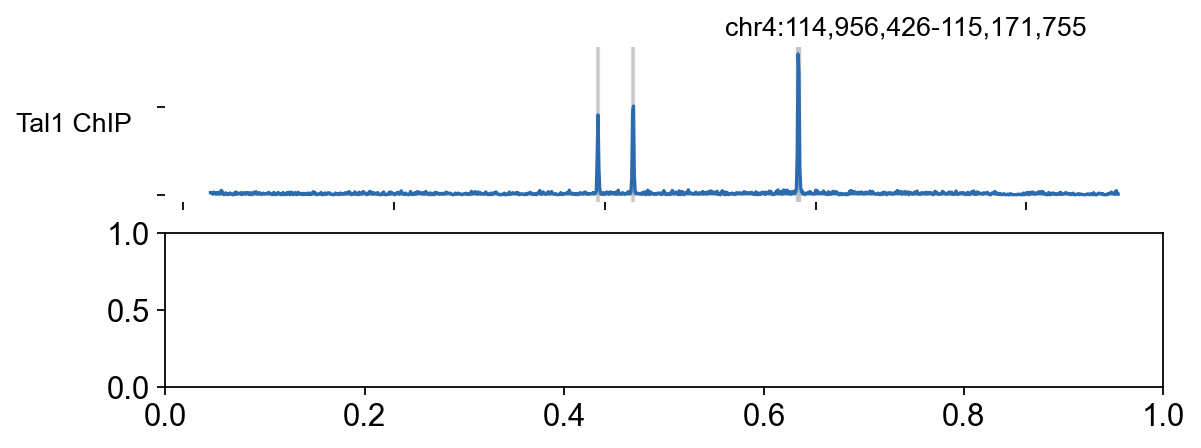

In [12]:
regions_df = pd.read_csv(regions_bed, sep='	', header=None, names=['chrom', 'start', 'end', 'name'])
tal1_row = regions_df[regions_df['name'].str.lower() == 'tal1'].iloc[0]

TAL1_LOCUS = (str(tal1_row['chrom']), int(tal1_row['start']), int(tal1_row['end']))

peak_file = OUT / 'peaks' / 'G1E_Tal1_peaks.narrowPeak'
merged_chip_bw = str(OUT / 'merged' / 'Tal1.rpkm.bw')
merged_input_bw = str(OUT / 'merged' / 'Input.rpkm.bw')

peak_df = pd.read_csv(peak_file, sep='	', header=None)
peak_df = peak_df[peak_df[0] == TAL1_LOCUS[0]].copy()
peak_df = peak_df[(peak_df[1] < TAL1_LOCUS[2]) & (peak_df[2] > TAL1_LOCUS[1])]
region_dict = {
    f'peak_{i+1}': (int(r[1]), int(r[2]))
    for i, r in peak_df.head(8).iterrows()
}

bw_obj = epi.bulk.bigwig({'Tal1 ChIP': merged_chip_bw, 'Input': merged_input_bw})
bw_obj.read()
color_dict = {'Tal1 ChIP': '#2B6CB0', 'Input': '#B0B0B0'}



bw_obj.plot_track(
    chrom=TAL1_LOCUS[0],
    chromstart=TAL1_LOCUS[1],
    chromend=TAL1_LOCUS[2],
    plot_names=['Tal1 ChIP', 'Input'],
    figwidth=8,
    figheight=2.8,
    color_dict=color_dict,
    bp_per_bin=200,
    region_dict=region_dict,
)


## 8. Compute a TSS heatmap for the merged ChIP signal

The local browser view asks whether the `Tal1` locus looks sensible. The TSS-centred heatmap asks a broader question: when the merged ChIP signal is summarized around annotated promoters on `chr4`, does it show structured enrichment rather than flat background?

To keep the annotation consistent with the reduced reference, we derive a transcript-only `chr4` GTF from the matching mouse GENCODE `gff3` file through `epi.utils.convert_gff_to_gtf(...)`.


In [9]:
GENCODE_GFF3 = pathlib.Path(epi.align.fetch_genome_annotation('GRCm38'))
CHR4_GTF = REF_DIR / 'gencode_vM25_chr4.transcripts.gtf'
CHR4_GTF = pathlib.Path(
    epi.utils.convert_gff_to_gtf(
        GENCODE_GFF3,
        CHR4_GTF,
        feature_whitelist=['transcript'],
        seqname_whitelist=['chr4'],
    )
)

with open(CHR4_GTF) as fin:
    transcript_count = sum(1 for _ in fin)
print(CHR4_GTF, transcript_count)


└─ Converting GFF to GTF: /tmp/snapatac2/gencode_vM25_GRCm38.gff3.gz -> /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/ref/gencode_vM25_chr4.transcripts.gtf


└─ Wrote 7035 GTF records
/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/ref/gencode_vM25_chr4.transcripts.gtf 7035


In [13]:
CHR4_GTF='/scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/ref/gencode_vM25_chr4.transcripts.gtf'

└─ Load bigWig files
  └─ Loading Tal1 ChIP...
└─ Load GTF file
  ├─ Reading GTF...
  └─ Reading GTF file from /scratch/users/steorra/analysis/omicverse_dev/epione/case/otx2/galaxy_chipseq_demo/ref/gencode_vM25_chr4.transcripts.gtf...
  └─ GTF file read successfully
  └─ GTF loaded
└─ Compute matrix: Tal1 ChIP
  ├─ Prepare features
  ├─ Build matrices


Chromosomes: 100%|██████████| 1/1 [00:01<00:00,  1.54s/chr]

  └─ Finalize
  └─ Tal1 ChIP matrix finished
  └─ Tal1 ChIP tss matrix in bw_tss_scores_dict[Tal1 ChIP]
  └─ Tal1 ChIP tes matrix in bw_tes_scores_dict[Tal1 ChIP]
  └─ Tal1 ChIP body matrix in bw_body_scores_dict[Tal1 ChIP]


(<Figure size 256x208 with 1 Axes>,
 <Axes: title={'center': 'Tal1 ChIP TSS mean'}>)

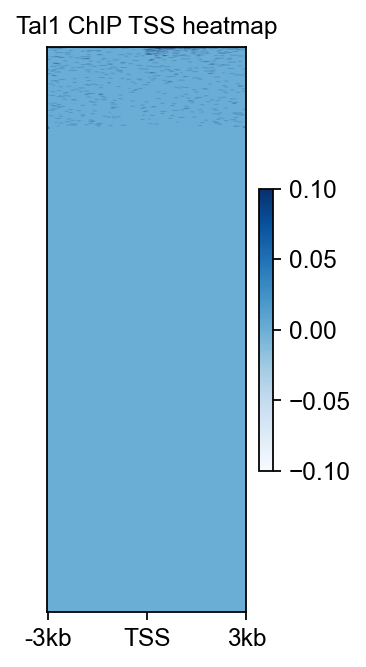

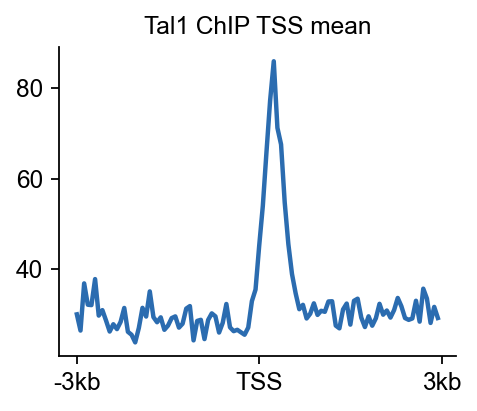

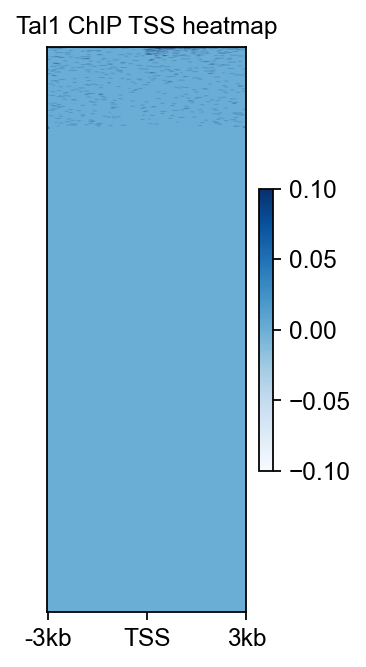

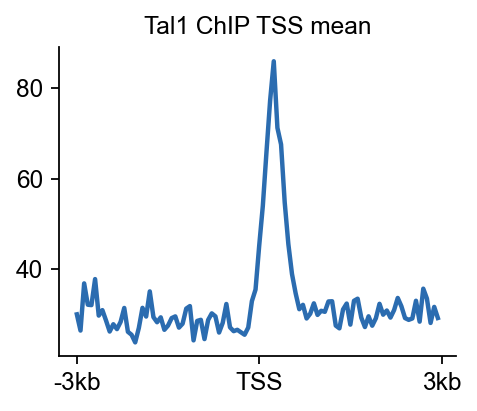

In [14]:
merged_chip_bw = str(OUT / 'merged' / 'Tal1.rpkm.bw')
chip_tss = epi.bulk.bigwig({'Tal1 ChIP': merged_chip_bw})
chip_tss.read()
chip_tss.load_gtf(str(CHR4_GTF))
chip_tss.compute_matrix('Tal1 ChIP', nbins=100, upstream=3000, downstream=3000, n_jobs=1)

fig, ax = chip_tss.plot_matrix(
    bw_name='Tal1 ChIP',
    bw_type='TSS',
    figsize=(2.4, 4.2),
    cmap='Blues',
    vmax='auto',
    vmin='auto',
    fontsize=11,
    title='Tal1 ChIP TSS heatmap',
)

chip_tss.plot_matrix_line(
    bw_name='Tal1 ChIP',
    bw_type='TSS',
    figsize=(3.2, 2.6),
    color='#2B6CB0',
    fontsize=11,
    title='Tal1 ChIP TSS mean',
)


## 9. OTX2 project template

The final cell shows the project handoff point using the same explicit ChIP/input preprocessing structure as the tutorial itself. Replace the tutorial FASTQs and the reduced `chr4` reference with your real project data, but keep the same step-by-step sequence of `epi.align.bowtie2`, `epi.align.samtools`, `epi.align.bigwig`, and `epi.align.macs2` calls.


In [11]:
# chip_rep1_dir = WORK / 'otx2_chip_upstream' / 'chip_rep1'
# input_rep1_dir = WORK / 'otx2_chip_upstream' / 'input_rep1'
# chip_rep1_dir.mkdir(parents=True, exist_ok=True)
# input_rep1_dir.mkdir(parents=True, exist_ok=True)
#
# chip_rep1_raw = chip_rep1_dir / 'chip_rep1.raw.bam'
# chip_rep1_bam = chip_rep1_dir / 'chip_rep1.filtered.bam'
# chip_rep1_bw = chip_rep1_dir / 'chip_rep1.rpkm.bw'
# input_rep1_raw = input_rep1_dir / 'input_rep1.raw.bam'
# input_rep1_bam = input_rep1_dir / 'input_rep1.filtered.bam'
# input_rep1_bw = input_rep1_dir / 'input_rep1.rpkm.bw'
#
# epi.align.bowtie2.align_fastq_to_bam(
#     fq1='/path/to/chip_rep1.fastq.gz',
#     fq2=None,
#     out_bam=chip_rep1_raw,
#     ref_index='/path/to/full/genome/index/prefix',
#     threads=8,
#     extra_args=['--very-sensitive'],
#     remove_duplicates=True,
# )
# epi.align.samtools.filter_bam(chip_rep1_raw, chip_rep1_bam, mapq=30, proper_pair=False, drop_secondary_supp=True, drop_unmapped=True, drop_mate_unmapped=False, threads=8)
# epi.align.samtools.index_bam(chip_rep1_bam, threads=8)
# epi.align.bigwig.bam_to_bigwig(chip_rep1_bam, chip_rep1_bw, bin_size=25, normalize_using='RPKM', threads=8)
#
# epi.align.bowtie2.align_fastq_to_bam(
#     fq1='/path/to/input_rep1.fastq.gz',
#     fq2=None,
#     out_bam=input_rep1_raw,
#     ref_index='/path/to/full/genome/index/prefix',
#     threads=8,
#     extra_args=['--very-sensitive'],
#     remove_duplicates=True,
# )
# epi.align.samtools.filter_bam(input_rep1_raw, input_rep1_bam, mapq=30, proper_pair=False, drop_secondary_supp=True, drop_unmapped=True, drop_mate_unmapped=False, threads=8)
# epi.align.samtools.index_bam(input_rep1_bam, threads=8)
# epi.align.bigwig.bam_to_bigwig(input_rep1_bam, input_rep1_bw, bin_size=25, normalize_using='RPKM', threads=8)
#
# merged_chip_bam = epi.align.samtools.merge_bams([chip_rep1_bam], WORK / 'otx2_chip_upstream' / 'chip.bam', threads=8)
# merged_input_bam = epi.align.samtools.merge_bams([input_rep1_bam], WORK / 'otx2_chip_upstream' / 'input.bam', threads=8)
# peak_paths = epi.align.macs2.call_peaks_macs2(
#     bam=merged_chip_bam,
#     control_bam=merged_input_bam,
#     out_dir=WORK / 'otx2_chip_upstream' / 'peaks',
#     name='chip_merged',
#     genome_size='mm',
#     format='BAM',
#     qvalue=0.01,
#     keep_dup='all',
#     call_summits=True,
#     nomodel=False,
# )
